## Ensemble Model



In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
# Import classifiers
from sklearn.ensemble import  GradientBoostingClassifier, RandomForestClassifier
import xgboost as xgb


In [ ]:
customer_data = pd.read_csv('/content/Churn_Modelling.csv')
# Droping the ineffective columns
dataset = customer_data.drop(['RowNumber', 'CustomerId', 'Surname'], axis = 1)


## Remove Outliers

In [ ]:
# Removing the outliers
dataset.drop(dataset[dataset['CreditScore'] <= 359].index, inplace = True)

dataset.drop(dataset[dataset['Age'] >= 71].index, inplace = True)

dataset.drop(dataset[dataset['NumOfProducts'] >= 4].index, inplace = True)

#Shape of Data after removing the outliers
print("Shape of Data after removing outliers: {}".format(dataset.shape))

## Feature Engineering

In [ ]:
dataset['BalanceSalary'] = dataset.Balance / dataset.EstimatedSalary
dataset['TenureAge'] = dataset.Tenure / (dataset.Age)
dataset['ScoreAge'] = dataset.CreditScore / (dataset.Age)

dataset['tenure_age'] = dataset.Tenure / (dataset.Age - 17)
dataset['tenure_salary'] = dataset.Tenure / (dataset.EstimatedSalary)
dataset['score_age'] = dataset.CreditScore / (dataset.Age - 17)
dataset['score_salary'] = dataset.CreditScore / (dataset.EstimatedSalary)

dataset["newAge"] = dataset["Age"] - dataset["Tenure"]
dataset["newCreditScore"] = pd.qcut(dataset['CreditScore'], 10, labels = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
dataset["AgeScore"] = pd.qcut(dataset['Age'], 8, labels = [1, 2, 3, 4, 5, 6, 7, 8])
dataset["BalanceScore"] = pd.qcut(dataset['Balance'].rank(method = "first"), 10, labels = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
dataset["SalaryScore"] = pd.qcut(dataset['EstimatedSalary'], 10, labels = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
dataset["newEstimatedSalary"] = dataset["EstimatedSalary"] / 12

dataset['score_balance'] = dataset.Balance / (dataset.CreditScore)
dataset['age_balance'] = dataset.Balance / (dataset.Age)
dataset['balance_salary'] = dataset.Balance / (dataset.EstimatedSalary)
dataset['age_hascrcard'] = dataset.HasCrCard / (dataset.Age)

In [ ]:

def product_utilization_rate_by_year(row):
    number_of_products = row.NumOfProducts
    tenure = row.Tenure #نرخ استفاده از محصول بر حسب سال‌ها 

    if number_of_products == 0:
        return 0
    if tenure == 0:
        return number_of_products

    rate = number_of_products / tenure
    return rate

def product_utilization_rate_by_salary(row):
    number_of_products = row.NumOfProducts
    estimated_salary = row.EstimatedSalary

    if number_of_products == 0:
        return 0

    rate = number_of_products / estimated_salary
    return rate

def countries_monthly_average_salaries(row):
    fr = 3696
    de = 4740
    sp = 2257
    salary = row.EstimatedSalary / 12
    country = row.Geography

    if country == 'Germany':
        return salary / de
    elif country == "France":
        return salary / fr
    elif country == "Spain":
        return salary / sp


In [ ]:

def feature_engineering(cus, is_show_graph = False):
    df_fe = dataset.copy()

    # product usage rate by year
    df_fe = df_fe.assign(product_utilization_rate_by_year = df_fe.apply(lambda x: product_utilization_rate_by_year(x), axis = 1))

    # product usage rate by estimated salary
    df_fe = df_fe.assign(product_utilization_rate_by_salary = df_fe.apply(lambda x: product_utilization_rate_by_salary(x), axis=1))

    # average monthly salary according to countries
    df_fe = df_fe.assign(countries_monthly_average_salaries = df_fe.apply(lambda x: countries_monthly_average_salaries(x), axis = 1))

    return df_fe
df_fe = feature_engineering(dataset)


In [ ]:
from sklearn.preprocessing import LabelEncoder

# To convert inputs to numeric values
encoder = LabelEncoder()
df_fe["Geography"] = encoder.fit_transform(df_fe["Geography"])
df_fe["Gender"] = encoder.fit_transform(df_fe["Gender"])

df_fe = df_fe.drop(['Geography', 'Gender'], axis = 1)
Geography = pd.get_dummies(dataset.Geography, drop_first = True)
Gender = pd.get_dummies(dataset.Gender).iloc[:, 0:]

In [ ]:
df_fe = pd.concat([df_fe, Geography, Gender], axis = 1)

In [ ]:

from sklearn.model_selection import train_test_split


X = df_fe.drop(["Exited"], axis=1)
sc = StandardScaler()
X =sc.fit_transform(X)
X=pd.DataFrame(X)
Y = df_fe["Exited"]



In [ ]:
from sklearn.model_selection import train_test_split

# Splitting the dataset into the Training set and Test set
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.2, random_state = 0)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

## Sampling

In [ ]:
from collections import Counter
from imblearn.over_sampling import SMOTEN

sm = SMOTEN()
X_smot_train, Y_smot_train = sm.fit_resample(X_train, y_train)
X_smot_test, Y_smot_test = sm.fit_resample(X_test, y_test)

print('Original dataset shape(Train): ', Counter(y_train))
print('Resampled dataset shape(Train): ', Counter(Y_smot_train))
print('\nOriginal dataset shape(Test): ', Counter(y_test))
print('Resampled dataset shape(Test): ', Counter(Y_smot_test))

## Random_Forest_Gradient_Boosting_Xgboost

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [21:25:15] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Accuracy: 0.92
Confusion Matrix:
[[1528   57]
 [ 212 1373]]
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1585
           1       0.96      0.87      0.91      1585

    accuracy                           0.92      3170
   macro avg       0.92      0.92      0.91      3170
weighted avg       0.92      0.92      0.91      3170



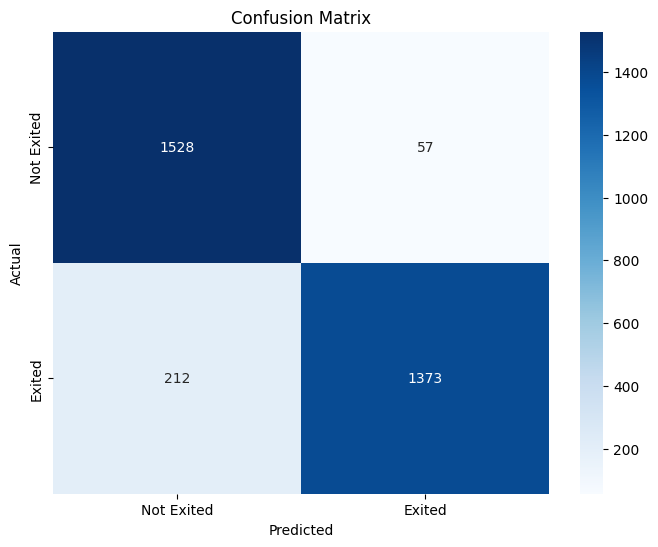

In [ ]:
# Import necessary libraries
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Define individual models
rf_model = RandomForestClassifier(n_estimators=90, random_state=0)
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=0)
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='auc', n_estimators=100)

# Create the VotingClassifier
voting_model = VotingClassifier(estimators=[
    ('rf', rf_model),
    ('gb', gb_model),
    ('xgb', xgb_model)
], voting='soft')  # 'soft' voting uses predicted probabilities

# Fit the model on the SMOTE training data
voting_model.fit(X_smot_train, Y_smot_train)

# Make predictions on the test set
y_pred = voting_model.predict(X_smot_test)

# Evaluate the model
accuracy = accuracy_score(Y_smot_test, y_pred)
conf_matrix = confusion_matrix(Y_smot_test, y_pred)
class_report = classification_report(Y_smot_test, y_pred)

# Print the results
print(f'Accuracy: {accuracy:.2f}')
print('Confusion Matrix:')
print(conf_matrix)
print('Classification Report:')
print(class_report)

# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Exited', 'Exited'], yticklabels=['Not Exited', 'Exited'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()



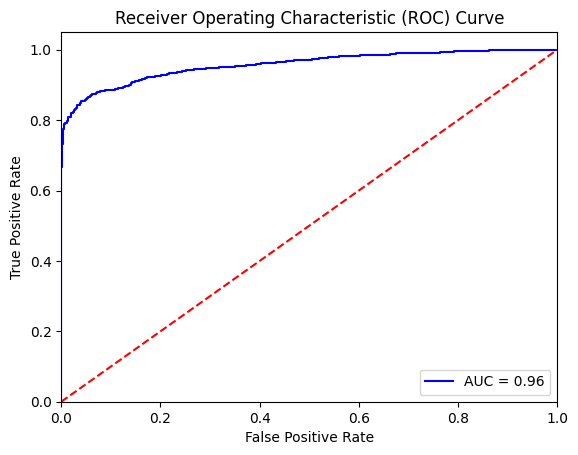

In [ ]:
# Calculate AUC
y_pred_proba = voting_model.predict_proba(X_smot_test)[:, 1]  # Probabilities for the positive class
auc = roc_auc_score(Y_smot_test, y_pred_proba)
# Plotting AUC Curve
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(Y_smot_test, y_pred_proba)
plt.figure()
plt.plot(fpr, tpr, color='blue', label='AUC = %0.2f' % auc)
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()